In [1]:
import matplotlib.pyplot as plt
import scienceplots  # This is required to register the styles
import numpy as np
import pickle

# Verify your numpy version
print(f"Using NumPy version: {np.__version__}") 

#plt.style.use(['science', 'ieee']) # Example of using the ieee style (readable figures in black&white print). Nature style is also nice for presentations - uses the sans-serif fonts.
#plt.style.use(['science', 'notebook', 'no-latex'])
plt.style.use(['science', 'no-latex']) 

#Figures standards:
'''- xmin=0 if we show nominal volume, area or such
- always center aqround the trend we want to show
- no log if possible 
- ticks with individual e values '''

Using NumPy version: 2.4.2


'- xmin=0 if we show nominal volume, area or such\n- always center aqround the trend we want to show\n- no log if possible \n- ticks with individual e values '

## Figures for IPAC:

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'no-latex', 'ieee'])
matplotlib.rcParams.update({'font.size': 9})
plt.rcParams['font.serif'] = 'Times New Roman'
dpi=150
figsize = (3.25, 3.25)

# inital benchmarks

In [ ]:




resolutions = ['25x25x50', '50x50x100','100x100x200', '125x125x250', '150x150x300', '175x175x350'] 

spacing_vals = []
stl_tol_vals = []
for r in resolutions:
    Nx, Ny, Nz = int(r.split('x')[0]), int(r.split('x')[1]), int(r.split('x')[2])
    spacing = [(xmax - xmin) / Nx, (ymax - ymin) / Ny, (zmax - zmin) / Nz]
    spacing_vals.append(spacing)
    x,y,z = np.linspace(xmin, xmax, Nx), np.linspace(ymin, ymax, Ny), np.linspace(zmin, zmax, Nz)
    stl_tolerance = np.min([np.min(np.diff(x)), np.min(np.diff(y)), np.min(np.diff(z))]) *stl_tol
    stl_tol_vals.append(stl_tolerance)

#for plotting
spacing_vals = np.array(spacing_vals)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(resolutions, stl_tol_vals, marker='o')
ax[0].set_yscale('log')
ax[0].set_xlabel('Resolution')
ax[0].set_ylabel('STL tolerance')
ax[0].set_title('STL Tolerance vs Resolution')
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(True, which='both', ls='-')

# plot spacing components vs resolution
ax[1].plot(resolutions, spacing_vals[:,0], marker='o', label='dx')
ax[1].plot(resolutions, spacing_vals[:,1], marker='s', label='dy')
ax[1].plot(resolutions, spacing_vals[:,2], marker='^', label='dz')
ax[1].set_yscale('log')
ax[1].set_xlabel('Resolution')
ax[1].set_ylabel('Spacing')
ax[1].set_title('Grid Spacing vs Resolution')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend()
ax[1].grid(True, which='both', ls='-')

plt.tight_layout()
plt.show()



In [ ]:
with open('clara_pvMesh_benchmark_results_0.pkl', 'rb') as f:
    results = pickle.load(f)

In [ ]:
sub_methods = ['Extract', 'Triangulate', 'Reconstruct']
line_styles = ['-', '--', '-.']

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results.items():
    # Sort resolutions
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')))
    
    # 1. Volume Plot (Standard line)
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    # Grab the color of the first plot to reuse it for the area lines
    p = ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    current_color = p[0].get_color() 
    
    # 2. Area Plot (Multi-line)
    # res_dict[r]['area_err'] is expected to be a list/array of 3 values
    for i in range(3):
        errors_area = [res_dict[r]['area_err'][i] for r in sorted_resolutions]
        
        # Only add to legend if it's the first method to avoid duplicate labels
        label = f"{method} ({sub_methods[i]})"
        
        ax[1].plot(sorted_resolutions, errors_area, 
                   color=current_color, 
                   linestyle=line_styles[i], 
                   marker='o', 
                   markersize=4,
                   label=label)
        
for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Retrieval Convergence')
# Place legend outside if it gets too crowded
ax[1].legend(fontsize='x-small', ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_1.pkl', 'rb') as f:
    results1 = pickle.load(f)


fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for method, res_dict in results1.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    #errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    #ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract_0 = [res_dict[r]['area_err'][0] for r in sorted_resolutions]
    ax[0].plot(sorted_resolutions, errors_extract_0, marker='o', label=method)
    errors_extract_1 = [res_dict[r]['area_err'][1] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract_1, marker='o', label=method)
    errors_extract_2 = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[2].plot(sorted_resolutions, errors_extract_2, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)


ax[0].set_ylabel('Area Error (%)')
ax[1].set_ylabel('Area Error (%)')
ax[2].set_ylabel('Area Error (%)')
ax[0].set_title('Surface extract Area Convergence')
ax[1].set_title('Triangulate Area Convergence')
ax[2].set_title('Reconstruct Area Convergence')

# Place legend outside if it gets too crowded
ax[0].legend()
ax[1].legend()
ax[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_1.pkl', 'rb') as f:
    results1 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results1.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_2-stltol&interiormethod.pkl', 'rb') as f:
    results2 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in {k: v for k, v in results2.items() if k != 'interior_points'}.items():
for method, res_dict in {k: v for k, v in results2.items()}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_3.pkl', 'rb') as f:
    results3 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results3.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_4.pkl', 'rb') as f:
    results4 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results4.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_5.pkl', 'rb') as f:
    results5 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results5.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_5_test0.pkl', 'rb') as f:
    results50 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results50.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_6.pkl', 'rb') as f:
    results6 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results6.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_6_test0.pkl', 'rb') as f:
    results60 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results60.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_6_test1.pkl', 'rb') as f:
    results61 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results61.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
with open('clara_pvMesh_benchmark_results_6_test2.pkl', 'rb') as f:
    results62 = pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results62.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle 

with open('clara_pvMesh_benchmark_results_6_test4.pkl', 'rb') as f:
    results64= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results64.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle 

with open('clara_pvMesh_benchmark_results_6_test6.pkl', 'rb') as f:
    results64= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results64.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle 

with open('clara_pvMesh_benchmark_results_6_test60.pkl', 'rb') as f:
    results64= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results64.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle 

with open('clara_pvMesh_benchmark_results_8_test0.pkl', 'rb') as f:
    results64= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for method, res_dict in results64.items():
#for method, res_dict in {k: v for k, v in results5.items() if k not in ['voxelize_rectlinear']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle 

with open('clara_pvMesh_benchmark_results_8_test0.pkl', 'rb') as f:
    results8= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results8.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

# The Fingers

In [ ]:

with open('clara_pvMesh_bench_finger_res_0.pkl', 'rb') as f:
    results_finger0= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results_finger0.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:

with open('clara_pvMesh_bench_finger_res_1.pkl', 'rb') as f:
    results_finger1= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results_finger1.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:

with open('clara_pvMesh_bench_finger_res_2.pkl', 'rb') as f:
    results_finger2= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results_finger2.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt
import scienceplots  # This is required to register the styles
import numpy as np
import pickle

# Verify your numpy version
print(f"Using NumPy version: {np.__version__}") 

#plt.style.use(['science', 'ieee']) # Example of using the ieee style (readable figures in black&white print). Nature style is also nice for presentations - uses the sans-serif fonts.
plt.style.use(['science', 'notebook', 'no-latex'])


Using NumPy version: 2.4.2


Voxelize_rectilinear optimal spacing 

In [3]:
import pyvista as pv
stl_finger= 'clara_stl_files/012_LHC_WVM_6L2-cube.stl'
surf_finger= pv.read(stl_finger)

xmin, xmax, ymin, ymax, zmin, zmax = surf_finger.bounds
Nx, Ny, Nz = 185,185,370
x = np.linspace(xmin, xmax, Nx)
y = np.linspace(ymin, ymax, Ny)
z = np.linspace(zmin, zmax, Nz)
spacing=[x[1]-x[0], y[1]-y[0], z[1]-z[0]]
print(spacing)


[np.float64(0.6545806345732288), np.float64(0.6545803650565745), np.float64(0.24941330162812392)]


In [4]:
[0.65, 0.65, 0.25]

[0.65, 0.65, 0.25]

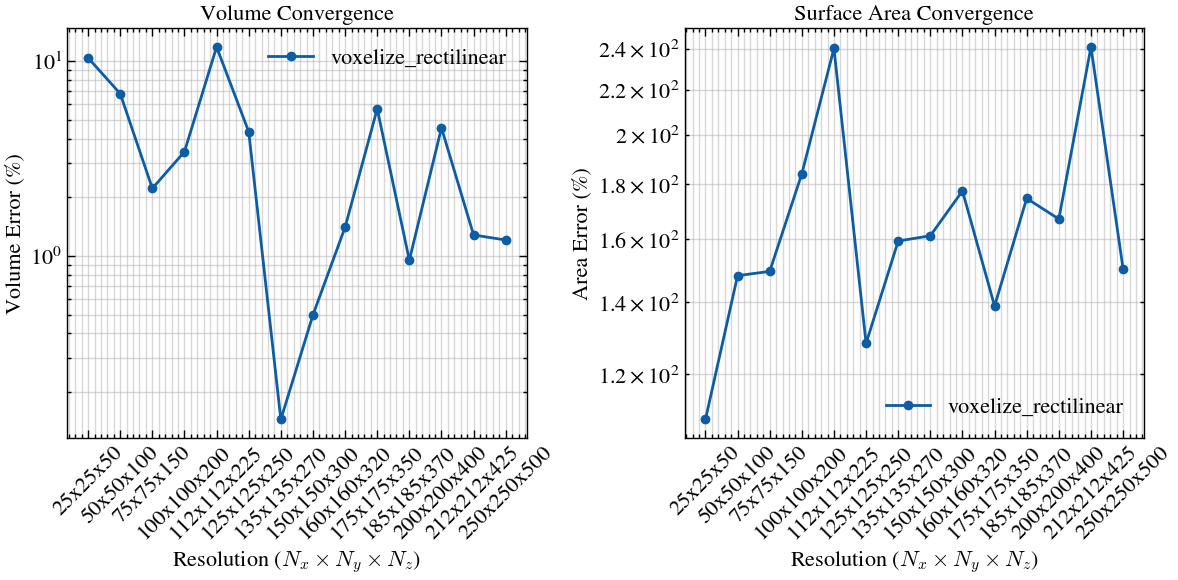

In [6]:

with open('clara_gridres_benchmark_results_0.pkl', 'rb') as f:
    results_finger2= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results_finger2.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()



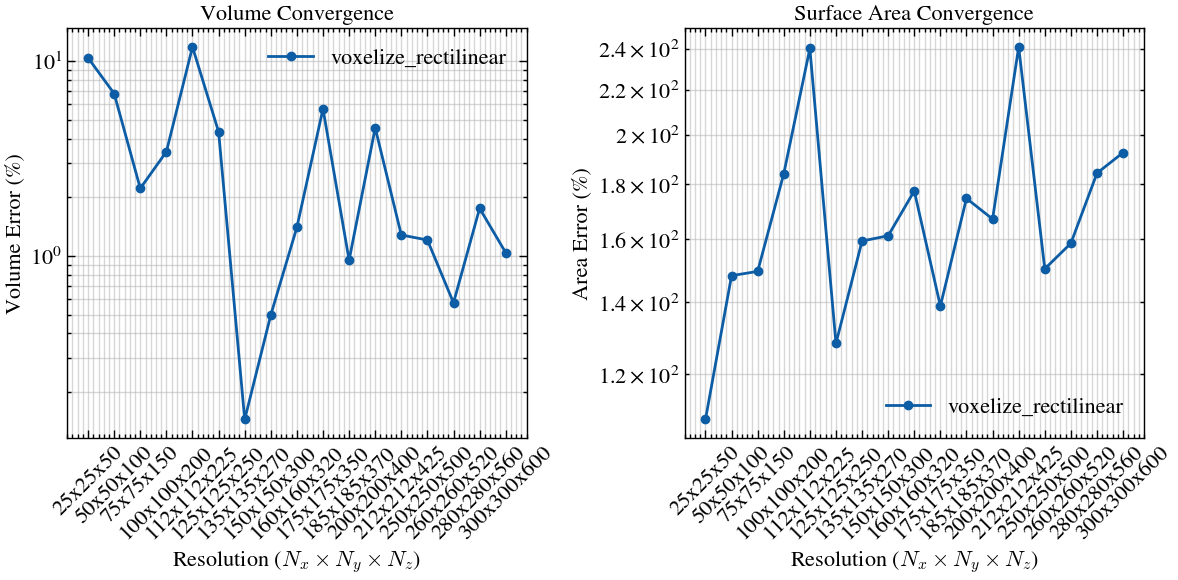

In [7]:

with open('clara_gridres_benchmark_results_1.pkl', 'rb') as f:
    results_finger2= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results_finger2.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()



/tmp/cwimmelm/ipykernel_458509/1017430297.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim([0,1e2])


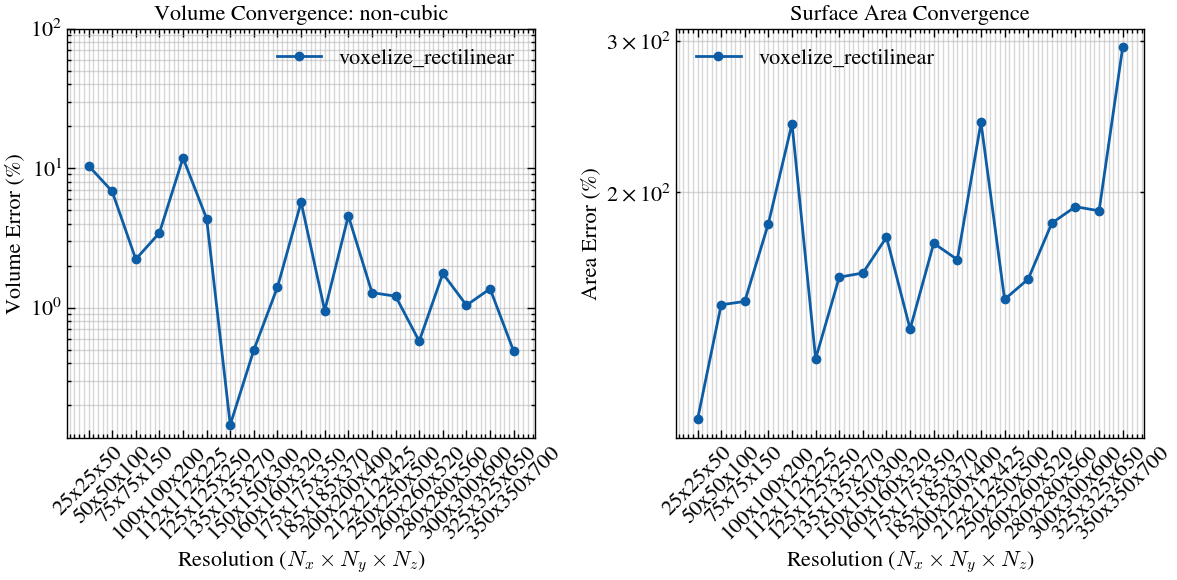

In [19]:

with open('clara_gridres_benchmark_results_2.pkl', 'rb') as f:
    results_finger2= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results_finger2.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_ylim([0,1e2])
ax[0].set_title('Volume Convergence: non-cubic')
ax[0].legend()

#ax[1].set_ylim([0,1e2])
ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()



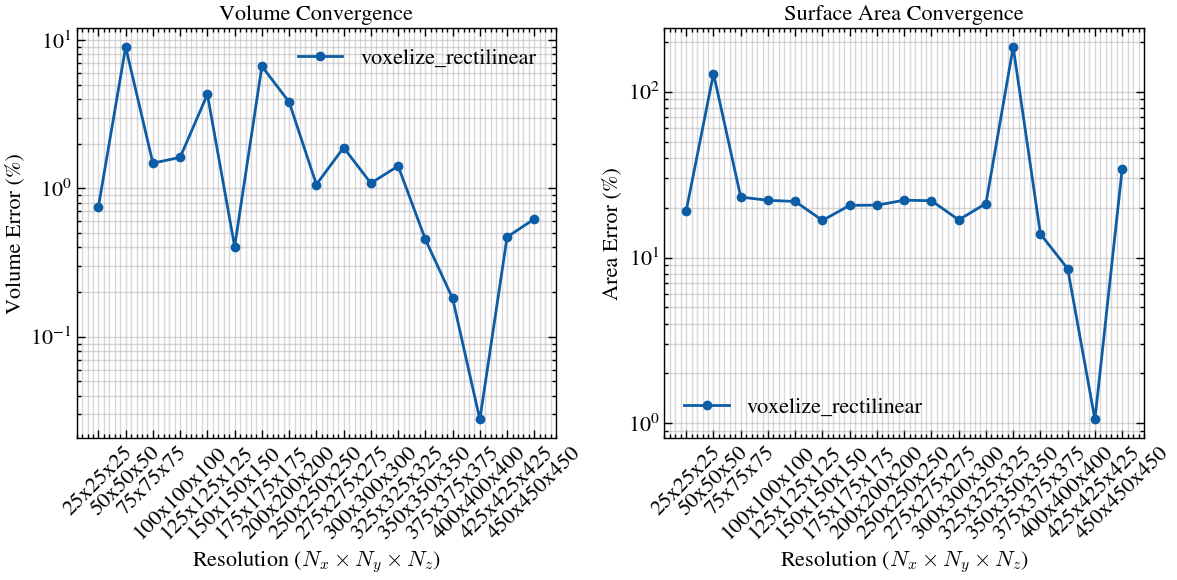

In [9]:

with open('clara_gridres_benchmark_results_3.pkl', 'rb') as f:
    results_finger2= pickle.load(f)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#for method, res_dict in results64.items():
for method, res_dict in {k: v for k, v in results_finger2.items() if k not in ['voxelize_rectilinea']}.items():
    #sort by total voxel count (Nx*Ny*Nz)
    sorted_resolutions = sorted(res_dict.keys(), 
                                key=lambda x: eval(x.replace('x', '*')), 
                                reverse=False)
    
    errors_vol = [res_dict[r]['vol_err'] for r in sorted_resolutions]
    errors_area = [res_dict[r]['area_err'] for r in sorted_resolutions]
    
    ax[0].plot(sorted_resolutions, errors_vol, marker='o', label=method)
    errors_extract = [res_dict[r]['area_err'][2] for r in sorted_resolutions]
    ax[1].plot(sorted_resolutions, errors_extract, marker='o', label=method)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'Resolution ($N_x \times N_y \times N_z$)')
    # Rotate labels on both axes properly
    a.tick_params(axis='x', rotation=45)
    a.grid(True, which="both", ls="-", alpha=0.5)

ax[0].set_ylabel('Volume Error (%)')
ax[0].set_title('Volume Convergence')
ax[0].legend()

ax[1].set_ylabel('Area Error (%)')
ax[1].set_title('Surface Area Convergence')
# Place legend outside if it gets too crowded
ax[1].legend()

plt.tight_layout()
plt.show()



# New GridFit3D benchmark to all objects , all methods , compared to nominal object volume 

shell:

In [ ]:
stl_cavity = "clara_stl_files/001_vacuum_cavity.stl"
stl_shell = "clara_stl_files/001_lossymetal_shell.stl"
stl_solids = {"cavity": stl_cavity, "shell": stl_shell}
stl_materials = {"cavity": "vacuum", "shell": [30, 1.0, 30]}
surf = pv.read(stl_shell) + pv.read(stl_cavity)
xmin, xmax, ymin, ymax, zmin, zmax = surf.bounds


import matplotlib.pyplot as plt
import numpy as np

methods= ['enclosed_points', 'interior_points', 'implicit_distance', 'voxelize_rectilinear']
#methods= ['interior_points', 'implicit_distance', 'voxelize_rectilinear']
resolutions = ['50x50x50','75x75x75','100x100x100', '125x125x125', '150x150x150', '175x175x175', '200x200x200'] 

plt.style.use(['science', 'no-latex'])


with open('clara_results/clara_gridresVScellsInside_perMethod_shell_1.pkl', 'rb') as f:
    results = pickle.load(f)

# --- Data Visualization (Convergence Plot) ---
plt.figure(figsize=(10, 6))

for m in methods:
    res_labels = [r for r in resolutions]
    cell_sizes = [((xmax-xmin)/int(r.split('x')[0])) * ((ymax-ymin)/int(r.split('x')[1])) * ((zmax-zmin)/int(r.split('x')[2])) for r in resolutions]
    vols = [results[(r, m)]['n_cells_inside'] * cs for r, cs in zip(resolutions, cell_sizes)]
    #counts = [results[(r, m)]['n_cells_inside'] for r in resolutions]
    plt.plot(res_labels, vols, marker='o', label=f'Method: {m}')

target_vol= pv.read(stl_shell).volume
plt.axhline(target_vol, color='k', linestyle='--', label='Target Volume')
plt.xlabel('Resolution (Nx x Ny x Nz)')
plt.ylabel('Number of Cells (Inside Shell)')
plt.title('Voxelization Convergence Analysis')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
'''
# --- Mesh Visualization (Optional: View the last resolution) ---
p = pv.Plotter()
last_res = resolutions[-1]
# Plotting the 'shell' threshold for the 'interior_points' method
p.add_mesh(inside_mask[(last_res, 'interior_points')], color="red", opacity=0.5, label="Voxelized Shell")
p.add_title(f"Voxelized Result: {last_res}")
p.show()'''

NameError: name 'pv' is not defined

6L2:

Target volume for Body: 0.00003817 cubic units
Target volume for Fingers: 0.00000766 cubic units
Target volume for Transition_tube: 0.00054260 cubic units
Target volume for Spring: 0.00000128 cubic units


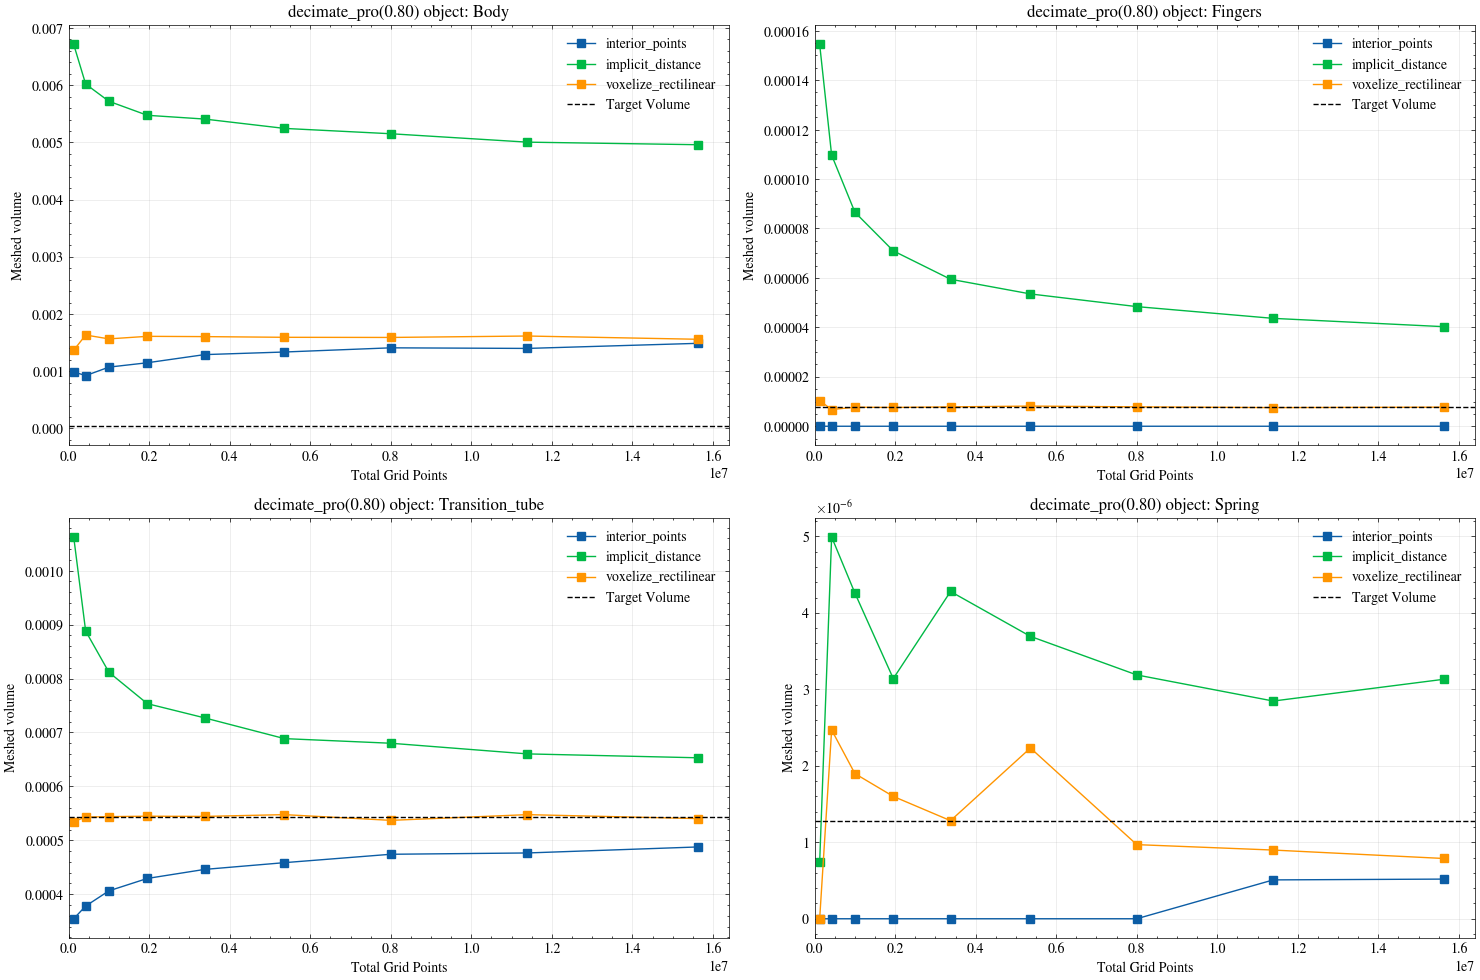

"\n# 5. Super Plot (Total Volume)\nplt.figure(figsize=(10, 6))\nfor method in methods:\n    total_cells = []\n    res_points = []\n    for r in resolutions:\n        total = sum(results[(r, method, k)]['n_cells_inside'] for k in object_keys)\n        res_points.append(eval(r.replace('x', '*')))\n        total_cells.append(total)\n    \n    sorted_indices = sorted(range(len(res_points)), key=lambda k: res_points[k])\n    plt.plot([res_points[j] for j in sorted_indices], \n             [total_cells[j] for j in sorted_indices], \n             marker='D', linewidth=2, label=method)\n\nplt.title('Super Plot: Total Voxelized Cells (All Objects Combined)')\nplt.xlabel('Total Grid Points')\nplt.ylabel('Sum of Cells')\nplt.legend()\nplt.grid(True)\nplt.show()"

In [46]:

methods = ["enclosed_points", "interior_points", "implicit_distance", "voxelize_rectilinear"]
methods = ["interior_points", "implicit_distance", "voxelize_rectilinear"]
resolutions = ['50x50x50','75x75x75','100x100x100', '125x125x125', '150x150x150', '175x175x175', '200x200x200','225x225x225', '250x250x250'] 

import pyvista as pv
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import scienceplots
plt.style.use(['science', 'no-latex'])

stl_body = 'clara_stl_files/012_LHC_WVM_6L2-316l_meters.stl'
stl_fingers = 'clara_stl_files/012_LHC_WVM_6L2-cube_meters.stl'
stl_cucamera = 'clara_stl_files/012_LHC_WVM_6L2-cucamera_meters.stl'
stl_martensite = 'clara_stl_files/012_LHC_WVM_6L2-martensite_meters.stl'
stl_materials = {'Body': [1e4, 1., 1e4], 'Fingers': [1e4, 1., 1e4], 
             'Transition tube': [1e4, 1., 1e4], 'Spring': [1e4, 1., 1e4]}
stl_solids = {'Body': stl_body, 
             'Fingers': stl_fingers, 
             'Transition_tube': stl_cucamera, 
             'Spring': stl_martensite
             }
surf=pv.read(stl_body) + pv.read(stl_fingers) + pv.read(stl_cucamera) + pv.read(stl_martensite)
# Domain bounds
xmin, xmax, ymin, ymax, zmin, zmax = surf.bounds

with open('clara_results/6l2_highRes/clara_gridresVScellsInside_perMethod_perObject_decimatePRO80.pkl', 'rb') as f:
    results = pickle.load(f)
'''with open('clara_results/6l2_highRes/clara_gridresVScellsInside_perMethod_perObject.pkl', 'rb') as f:
    results = pickle.load(f)
'''
'''colors= as the exact ones now
colors_pro= one shade darker than the original colors, e.g. using a colormap or manually defining them
'''

# Extract unique keys (Body, Fingers, etc.)
object_keys = list(stl_solids.keys())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# 4 Subplots for individual objects
for i, key in enumerate(object_keys):
    ax = axes[i]
    subsurf=pv.read(stl_solids[key])
    target_vol=subsurf.volume
    print(f"Target volume for {key}: {target_vol:.8f} cubic units")
    for m in methods:
        res_list = []
        cells_list = []
        vol_list=[]
        for r in resolutions:
            Nx, Ny, Nz = map(int, r.split('x'))
            cell_size= (xmax-xmin)/Nx * (ymax-ymin)/Ny * (zmax-zmin)/Nz
            res_list.append(eval(r.replace('x', '*'))) # quick way to get total points
            cells_list.append(results[(r, m, key)]['n_cells_inside'])
            vol_list.append(results[(r, m, key)]['n_cells_inside'] * cell_size)
        
        # Sort by resolution for a clean line
        sorted_indices = sorted(range(len(res_list)), key=lambda k: res_list[k])
        '''ax.plot([res_list[j] for j in sorted_indices], 
                [cells_list[j] for j in sorted_indices], 
                marker='s', label=m)'''
        ax.plot([res_list[j] for j in sorted_indices], 
                [vol_list[j] for j in sorted_indices], 
                marker='s', label=m)
        
    
    xfmt = ScalarFormatter(useMathText=False)
    xfmt.set_powerlimits((0, 0))
    xfmt.set_useOffset(False)
    ax.xaxis.set_major_formatter(xfmt)
    
    ax.axhline(target_vol, color='k', linestyle='--', label='Target Volume')
    ax.set_title(f'decimate_pro(0.80) object: {key}')
    ax.set_xlabel('Total Grid Points')
    ax.set_ylabel('Meshed volume')
    ax.set_xlim(left=0)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
'''
# 5. Super Plot (Total Volume)
plt.figure(figsize=(10, 6))
for method in methods:
    total_cells = []
    res_points = []
    for r in resolutions:
        total = sum(results[(r, method, k)]['n_cells_inside'] for k in object_keys)
        res_points.append(eval(r.replace('x', '*')))
        total_cells.append(total)
    
    sorted_indices = sorted(range(len(res_points)), key=lambda k: res_points[k])
    plt.plot([res_points[j] for j in sorted_indices], 
             [total_cells[j] for j in sorted_indices], 
             marker='D', linewidth=2, label=method)

plt.title('Super Plot: Total Voxelized Cells (All Objects Combined)')
plt.xlabel('Total Grid Points')
plt.ylabel('Sum of Cells')
plt.legend()
plt.grid(True)
plt.show()'''

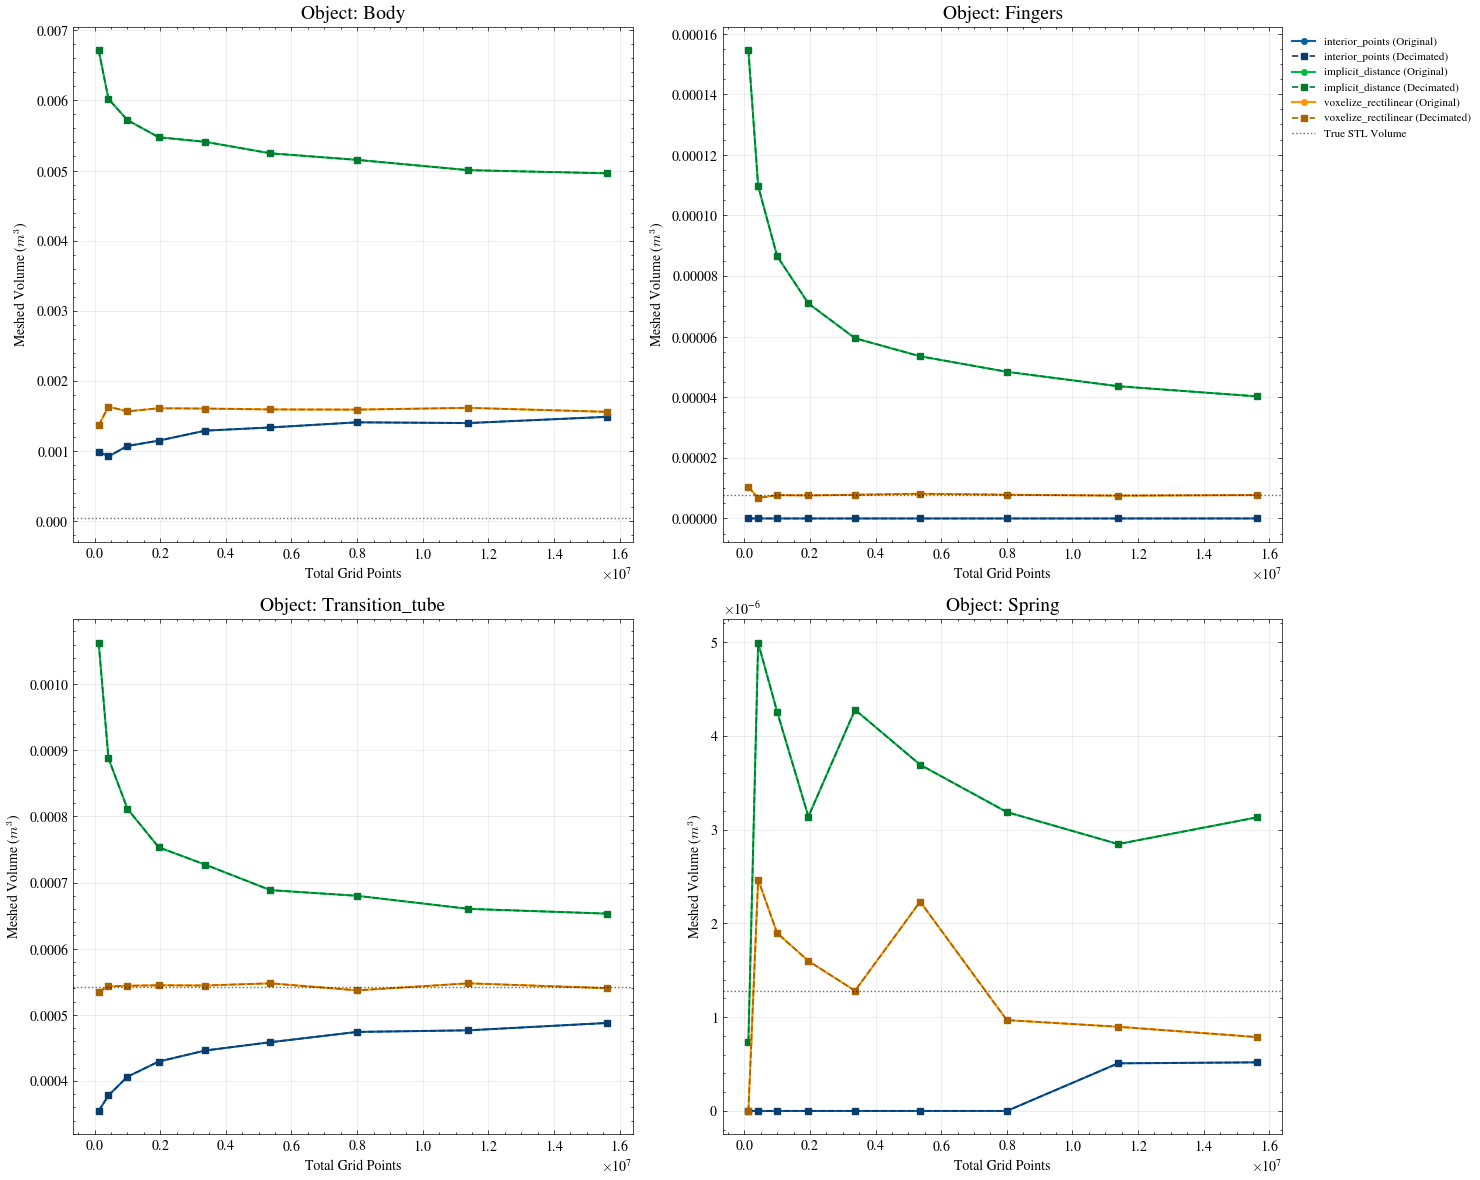

In [ ]:


with open('clara_results/6l2_highRes/clara_gridresVScellsInside_perMethod_perObject_decimatePRO80.pkl', 'rb') as f:
    results_dec = pickle.load(f)
with open('clara_results/6l2_highRes/clara_gridresVScellsInside_perMethod_perObject.pkl', 'rb') as f:
    results_og = pickle.load(f)

#take into account that results_og uses 'Transition tube' while results_dec uses 'Transition_tube' as key for the same object
stl_solids_dec = {'Body': stl_body, 
             'Fingers': stl_fingers, 
             'Transition_tube': stl_cucamera, 
             'Spring': stl_martensite
             }
stl_solids_og = {'Body': stl_body, 
             'Fingers': stl_fingers, 
             'Transition_tube': stl_cucamera, 
             'Spring': stl_martensite
             }


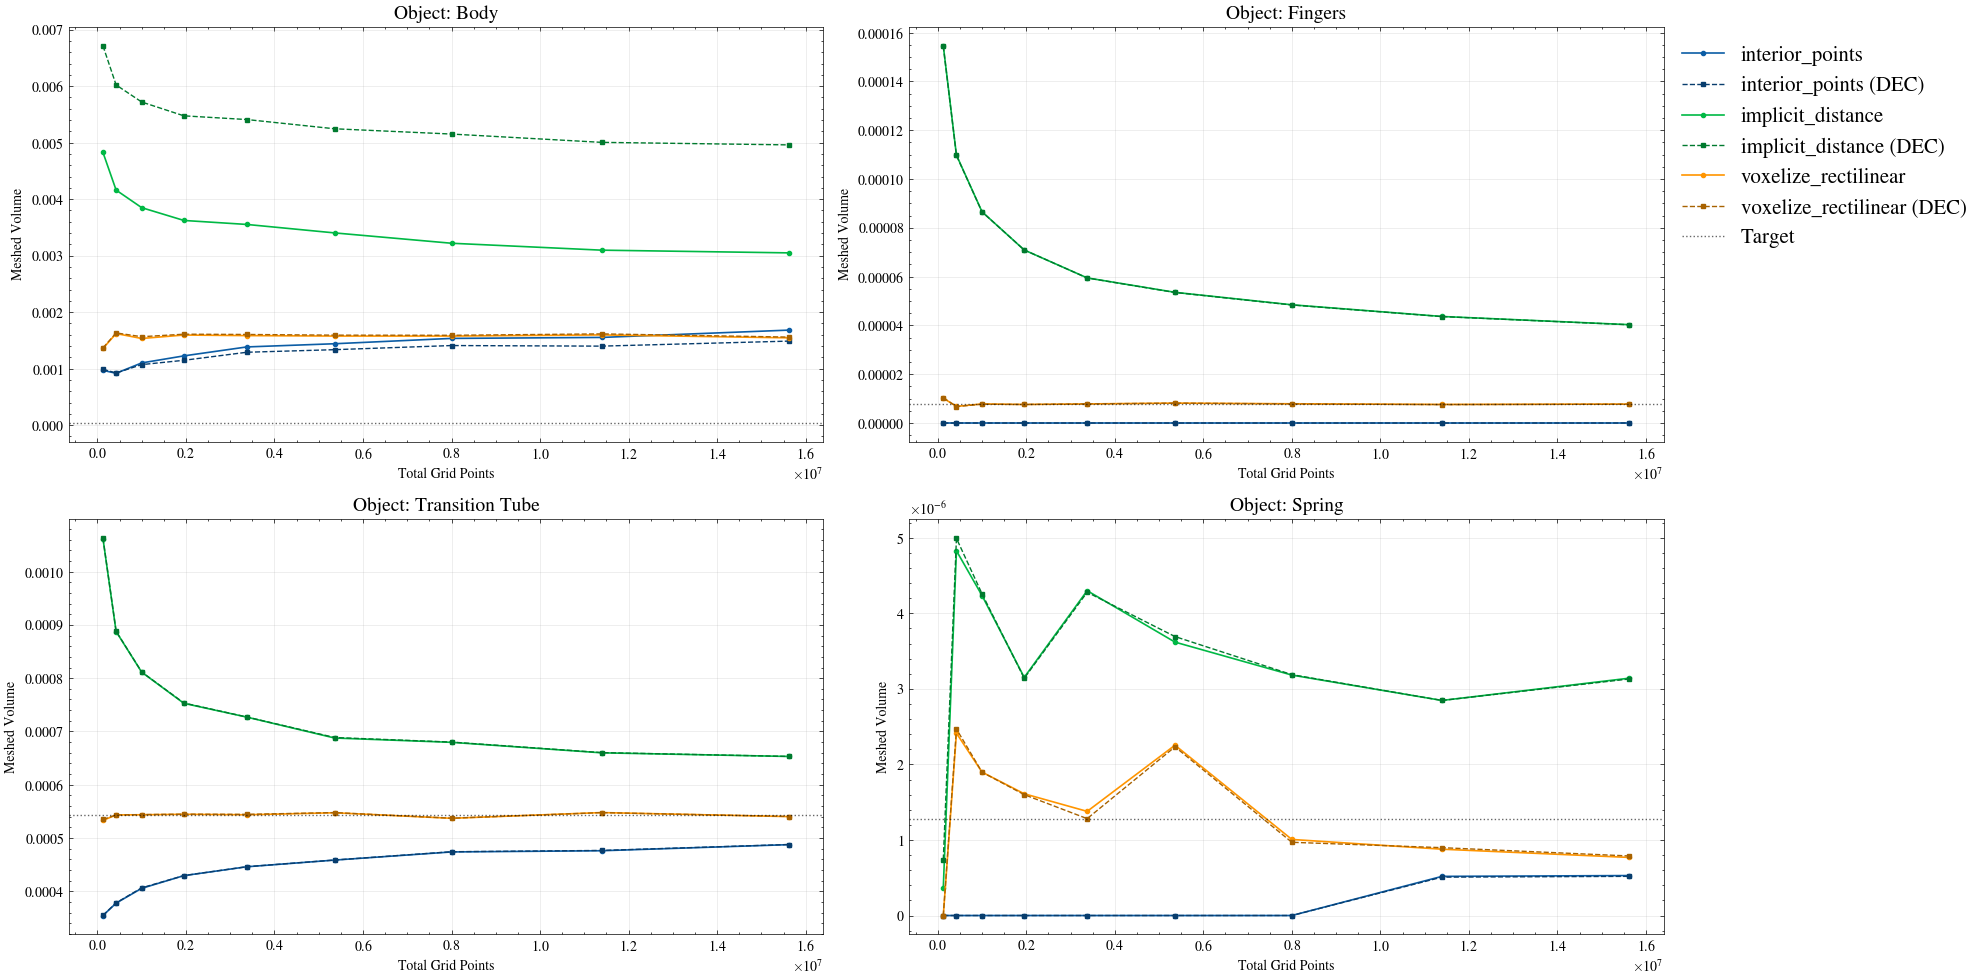

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import pyvista as pv



# 1. Setup the Color Mapping (Dictionary ensures consistency)
method_colors = {
    "enclosed_points": "#4C4C4C",      # Grey (Only in OG)
    "interior_points": "#0C5DA5",      # Blue
    "implicit_distance": "#00B945",    # Green
    "voxelize_rectilinear": "#FF9500"  # Orange
}

# Darker versions for the Decimated (PRO) lines
colors_pro = {
    "interior_points": "#083D6D",
    "implicit_distance": "#007A2E",
    "voxelize_rectilinear": "#A86200"
}

# 2. Bridge the naming gap
# Key: Plot Title, Value: (Key in results_og, Key in results_dec)
key_bridge = {
    'Body': ('Body', 'Body'),
    'Fingers': ('Fingers', 'Fingers'),
    'Transition Tube': ('Transition tube', 'Transition_tube'),
    'Spring': ('Spring', 'Spring')
}

plt.style.use(['science', 'no-latex'])
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

for i, (label, keys) in enumerate(key_bridge.items()):
    ax = axes[i]
    og_key, dec_key = keys
    
    # Use the decimated STL for the target volume reference
    subsurf = pv.read(stl_solids_dec[dec_key])
    target_vol = subsurf.volume
    
    # We iterate over OG methods as it is the "superset"
    for m in methods_og:
        res_points = []
        vol_og = []
        vol_dec = []
        
        for r in resolutions:
            Nx, Ny, Nz = map(int, r.split('x'))
            cell_vol = (xmax-xmin)/Nx * (ymax-ymin)/Ny * (zmax-zmin)/Nz
            total_pts = Nx * Ny * Nz
            res_points.append(total_pts)
            
            # Fetch OG Data
            og_val = results_og.get((r, m, og_key), {}).get('n_cells_inside', np.nan)
            vol_og.append(og_val * cell_vol)
            
            # Fetch DEC Data
            dec_val = results_dec.get((r, m, dec_key), {}).get('n_cells_inside', np.nan)
            vol_dec.append(dec_val * cell_vol)

        # Sort for clean lines
        idx = np.argsort(res_points)
        x_sorted = np.array(res_points)[idx]
        
        # Plot Original (Solid)
        if not np.all(np.isnan(vol_og)):
            ax.plot(x_sorted, np.array(vol_og)[idx], marker='o', markersize=3,
                    color=method_colors[m], label=f"{m}", linewidth=1.2)
        
        # Plot Decimated (Dashed + Darker)
        if not np.all(np.isnan(vol_dec)):
            ax.plot(x_sorted, np.array(vol_dec)[idx], marker='s', markersize=3,
                    color=colors_pro.get(m, method_colors[m]), linestyle='--', 
                    label=f"{m} (DEC)", linewidth=1.0)

    # Formatting Subplot
    ax.axhline(target_vol, color='k', linestyle=':', alpha=0.6, label='Target')
    ax.set_title(f'Object: {label}', fontsize=14)
    ax.set_xlabel('Total Grid Points')
    ax.set_ylabel('Meshed Volume')
    
    # Professional X-axis notation
    xfmt = ScalarFormatter(useMathText=True)
    xfmt.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(xfmt)
    ax.grid(True, alpha=0.3)
    
    if i == 1: # Unified Legend
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=15, ncol=1)

plt.tight_layout()
plt.show()

Run algorithms times, stacked bar plot:

In [3]:

with open('clara_results/6l2_highRes/clara_gridresVScellsInside_perMethod_Times_decimatePRO80.pkl', 'rb') as f:
    times = pickle.load(f)

methods = ["interior_points", "implicit_distance", "voxelize_rectilinear"]
resolutions = [
    '50x50x50','75x75x75','100x100x100', '125x125x125', '150x150x150', 
    '175x175x175', '200x200x200', '225x225x225', '250x250x250',
    '275x275x275','300x300x300','325x325x325','350x350x350', 
    '375x375x375', '400x400x400', '425x425x425', '450x450x450'
]

In [24]:
f

<_io.BufferedReader name='clara_results/6l2_highRes/clara_gridresVScellsInside_perMethod_Times_decimatePRO80.pkl'>

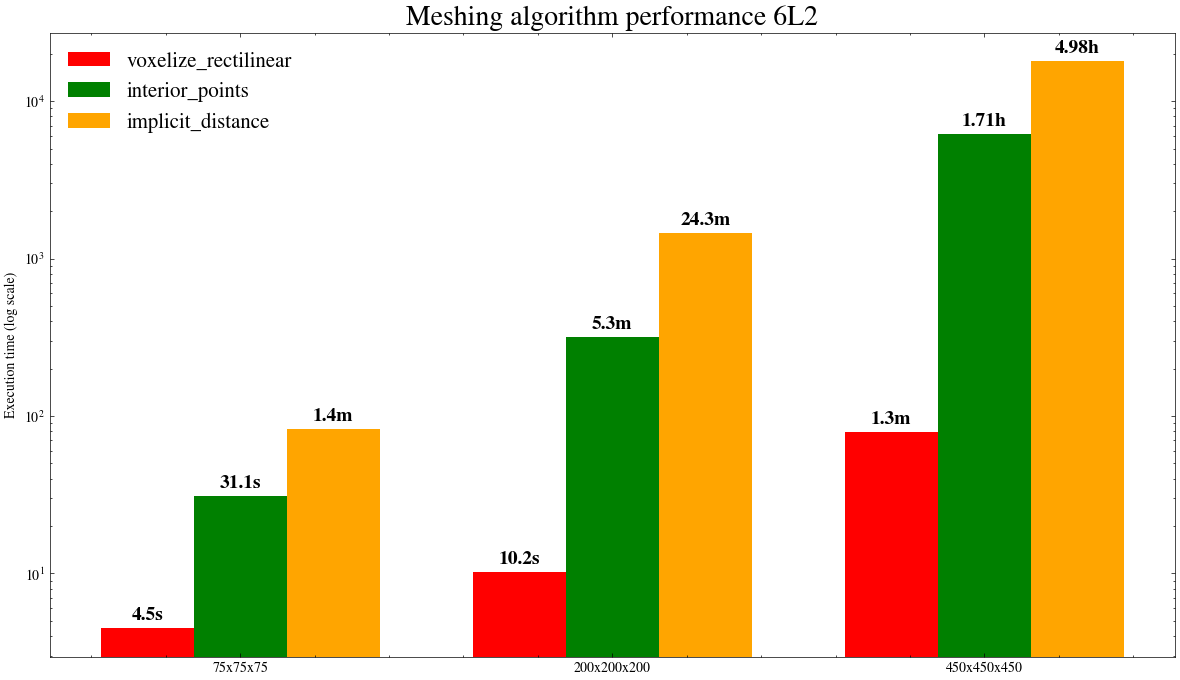

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load your data (assuming standard structure)
'''with open('clara_results/6l2_highRes/clara_gridresVScellsInside_perMethod_Times_decimatePRO80.pkl', 'rb') as f:
     times = pickle.load(f)
'''


with open('clara_results/clara_gridresVScellsInside_perMethod_Times.pkl', 'rb') as f:
    times = pickle.load(f)


methods = ["voxelize_rectilinear","interior_points", "implicit_distance"]
# Chosen resolutions: Low, Medium, High
selected_res = ['75x75x75', '200x200x200', '450x450x450']


def format_time(seconds):
    if seconds < 60:
        return f"{seconds:.1f}s"
    elif seconds < 3600:
        return f"{seconds/60:.1f}m"
    else:
        return f"{seconds/3600:.2f}h"
    
#colors = ["#BC4848", "#00B944B0", "#FF9500C0"] 
colors=['red', 'green', 'orange'] 

plt.style.use(['science', 'no-latex'])
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(selected_res))  # The label locations (0, 1, 2)
width = 0.25  # Width of each method bar
for i, m in enumerate(methods):
    heights = []
    labels = []
    
    for j, r in enumerate(selected_res):
        # Get raw time in seconds
        val_sec = times.get((r, m), {}).get('grid time:', 0)
        heights.append(val_sec)
        
        # Determine label unit based on resolution index
        if j == 0:    # Low: Seconds
            labels.append(f"{val_sec:.1f}s")
        elif j == 1:  # Medium: Minutes
            labels.append(f"{val_sec/60:.2f}m")
        else:         # High: Hours
            labels.append(f"{val_sec/3600:.3f}h")
            
    # Position each method bar side-by-side within the resolution group
    rects = ax.bar(x + (i - 1) * width, heights, width, label=m, color=colors[i])
    
    # Add the text labels on top of each bar
    #for k, rect in enumerate(rects):
    for rect, h in zip(rects, heights):
        ax.annotate(format_time(h), # Uses the logic: s if <60, m if <3600, else h
                xy=(rect.get_x() + rect.get_width() / 2, h),  # Position above the bar
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=14, fontweight='bold')
                
'''
labels[k],
xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
xytext=(0, 3),  # 3 points vertical offset
textcoords="offset points",
ha='center', va='bottom', fontsize=14, fontweight='bold')
'''

# Formatting
ax.set_title('Meshing algorithm performance 6L2', fontsize=20)
ax.set_ylabel('Execution time (log scale)')
ax.set_yscale('log') # Log scale is best when comparing seconds to hours
ax.set_xticks(x)
ax.set_xticklabels(selected_res)
ax.legend(fontsize=15)
ax.

plt.tight_layout()
plt.show()

# Decimate benchmark quantitativelly:

# Wakis simulation results 

In [7]:
import matplotlib.pyplot as plt
import scienceplots  # This is required to register the styles
import numpy as np
import pickle
from wakis import WakeSolver

In [8]:
wake = WakeSolver(sigmaz=50e-3)
#results_folder = f'/home/cwimmelm/cernbox/wakis/clara_data/012_results_noContactSCS_opening_27M/'
#results_folder = f'clara_data/SCS_opening_6L2/012_results_noContactSCS_opening_43M/'
#results_folder = f'clara_data/SCS_opening_6L2/012_results_noContactSCS_bcPEC_27M/'
results_folder = f'/home/cwimmelm/cernbox/wakis/clara_data/012_results_noContactSCS_PML_27M/'
wake.load_results(results_folder)
wake.solve(skip_cells=100)

Initializing Wakefield parameters...
Total solver initialization time: 0.00018072128295898438 s
Reading h5 file /home/cwimmelm/cernbox/wakis/clara_data/012_results_noContactSCS_PML_27M/Ez.h5
Size of the h5 file: 0.96 Gb
Calculating longitudinal wake potential WP(s)


100%|██████████| 718722/718722 [02:34<00:00, 4647.03it/s] 


Elapsed time 154.66302871704102 s
Calculating transverse wake potential WPx, WPy...


100%|██████████| 718722/718722 [00:09<00:00, 71896.10it/s] 


Elapsed time 9.99705171585083 s
Calculating longitudinal impedance Z...
Calculating transverse impedance Zx, Zy...
Calculation terminated in 165s


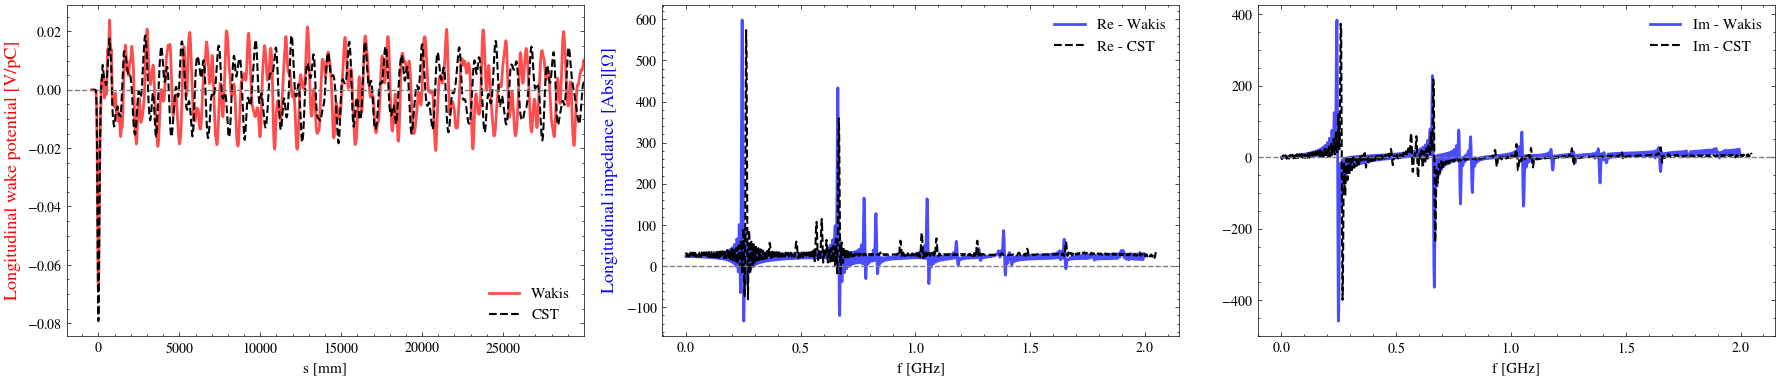

In [18]:
import matplotlib.pyplot as plt
#%matplotlib ipympl
#%matplotlib inline
import scienceplots
#plt.style.use(['science','ieee'])
plt.style.use(['science', 'no-latex']) 
# ----------- 1d plot results --------------------
# Plot longitudinal wake potential and impedance
from matplotlib import cm
plt.rcParams['text.usetex'] = False

fig1, ax = plt.subplots(1, 3, figsize=(18, 4))

'''
ax[0].tick_params(axis='both', labelsize=10)
ax[1].tick_params(axis='both', labelsize=10)
ax[2].tick_params(axis='both', labelsize=10)
ax[0].xaxis.label.set_fontsize(10)
ax[0].yaxis.label.set_fontsize(10)
ax[1].xaxis.label.set_fontsize(10)
ax[1].yaxis.label.set_fontsize(10)
ax[2].xaxis.label.set_fontsize(10)
ax[2].yaxis.label.set_fontsize(10)
'''

ax[0].plot(wake.s * 1e3, wake.WP, c="r", lw=2, alpha=0.7, label="Wakis")
ax[0].set_xlabel("s [mm]",fontsize=11)
ax[0].set_ylabel("Longitudinal wake potential [V/pC]", color="r",fontsize=13)
ax[0].legend()
ax[0].set_xlim(xmax=wake.s[-1] * 1e3)

ax[1].plot(wake.f * 1e-9, np.real(wake.Z), c="b", lw=2, alpha=0.7, label="Re - Wakis")
ax[2].plot(wake.f * 1e-9, np.imag(wake.Z), c="b", lw=2, alpha=0.7, label="Im - Wakis")
ax[1].set_xlabel("f [GHz]",fontsize=11)
ax[2].set_xlabel("f [GHz]",fontsize=11)
ax[1].set_ylabel("Longitudinal impedance [Abs][$\Omega$]", color="b",fontsize=13)


#cstWP_4 = wake.read_txt(f'cst/WP_6L2_allPEC_meshref_45.txt')
#cstZ_4 = wake.read_txt(f'cst/Z_6L2_allPEC_meshref_45.txt')
cstWP_4 = wake.read_txt(f'/home/cwimmelm/cernbox/wakis/clara_results/CST_benchmarks/6l2/WP_6L2_meshref_50.txt')
cstZ_4 = wake.read_txt(f'/home/cwimmelm/cernbox/wakis/clara_results/CST_benchmarks/6l2/Z_6L2_meshref_50.txt')
#colors = cm.Reds(np.linspace(0.2, 0.8, 4))

ax[0].plot(cstWP_4[0], cstWP_4[1], c="k",ls='--', lw=1.5, label="CST")
ax[1].plot(cstZ_4[0], cstZ_4[1], c="k", ls='--', lw=1.5, label="Re - CST")
ax[2].plot(cstZ_4[0], cstZ_4[2], c="k", ls='--', lw=1.5, label="Im - CST")
ax[0].axhline(0, c='grey', ls='--', lw=1)
ax[1].axhline(0, c='grey', ls='--', lw=1)
ax[2].axhline(0, c='grey', ls='--', lw=1)
ax[0].legend(fontsize=11)
ax[1].legend(fontsize=11)
ax[2].legend(fontsize=11)
fig1.tight_layout()
fig1.savefig(results_folder + "001_longitudinal_100add.png")
plt.show()

In [1]:
import matplotlib.pyplot as plt
import scienceplots  
import numpy as np
import pickle

# Verify your numpy version
print(f"Using NumPy version: {np.__version__}") 

#plt.style.use(['science', 'ieee']) # Example of using the ieee style (readable figures in black&white print). Nature style is also nice for presentations - uses the sans-serif fonts.
#plt.style.use(['science', 'notebook', 'no-latex'])
plt.style.use(['science', 'no-latex']) 

#Figures standards:
'''- xmin=0 if we show nominal volume, area or such
- always center aqround the trend we want to show
- no log if possible 
- ticks with individual e values '''

Using NumPy version: 2.4.2


'- xmin=0 if we show nominal volume, area or such\n- always center aqround the trend we want to show\n- no log if possible \n- ticks with individual e values '

In [2]:
result_folder= '/home/cwimmelm/cernbox/wakis/clara_results/simulation_results/voxelize_rectilinear_HTCondor/6l2_ttubeClosed_210x245x254_pec_wl3000_2'

WP=np.loadtxt(f"{result_folder}/WP.txt", skiprows=2,delimiter=None, usecols=None)
Z=np.loadtxt(f"{result_folder}/Z.txt", skiprows=2, delimiter=None, usecols=None, dtype=complex)
cstWP = np.loadtxt("/home/cwimmelm/cernbox/wakis/clara_results/CST_benchmarks/6l2/WP_6L2_closed_ttube_allPEC_NOmeshref_120.txt", skiprows=2, delimiter=None, usecols=None)
cstZ=np.loadtxt("/home/cwimmelm/cernbox/wakis/clara_results/CST_benchmarks/6l2/Z_6L2_closed_ttube_allPEC_NOmeshref_120.txt", skiprows=2,delimiter=None, usecols=None)

In [3]:
cstZ=np.loadtxt('/home/cwimmelm/cernbox/wakis/clara_results/CST_benchmarks/6l2/Z_nmesh10M_wk3e4.txt')
cstWP=np.loadtxt('/home/cwimmelm/cernbox/wakis/clara_results/CST_benchmarks/6l2/WP_nmesh10M_wk3e4.txt')

In [4]:
result_folder= '/home/cwimmelm/cernbox/wakis/clara_results/simulation_results/voxelize_rectilinear_HTCondor/ttubeClosed_210x245x254_pec_wl3000'

WP=np.loadtxt(f"{result_folder}/WP.txt", skiprows=2,delimiter=None, usecols=None)
Z=np.loadtxt(f"{result_folder}/Z.txt", skiprows=2, delimiter=None, usecols=None, dtype=complex)
cstWP = np.loadtxt("/home/cwimmelm/cernbox/wakis/clara_results/CST_benchmarks/6l2/WP_6L2_closed_ttube_allPEC_NOmeshref_120.txt", skiprows=2, delimiter=None, usecols=None)
cstZ=np.loadtxt("/home/cwimmelm/cernbox/wakis/clara_results/CST_benchmarks/6l2/Z_6L2_closed_ttube_allPEC_NOmeshref_120.txt", skiprows=2,delimiter=None, usecols=None)

/home/cwimmelm/miniforge3/envs/wakis-env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/cwimmelm/miniforge3/envs/wakis-env/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


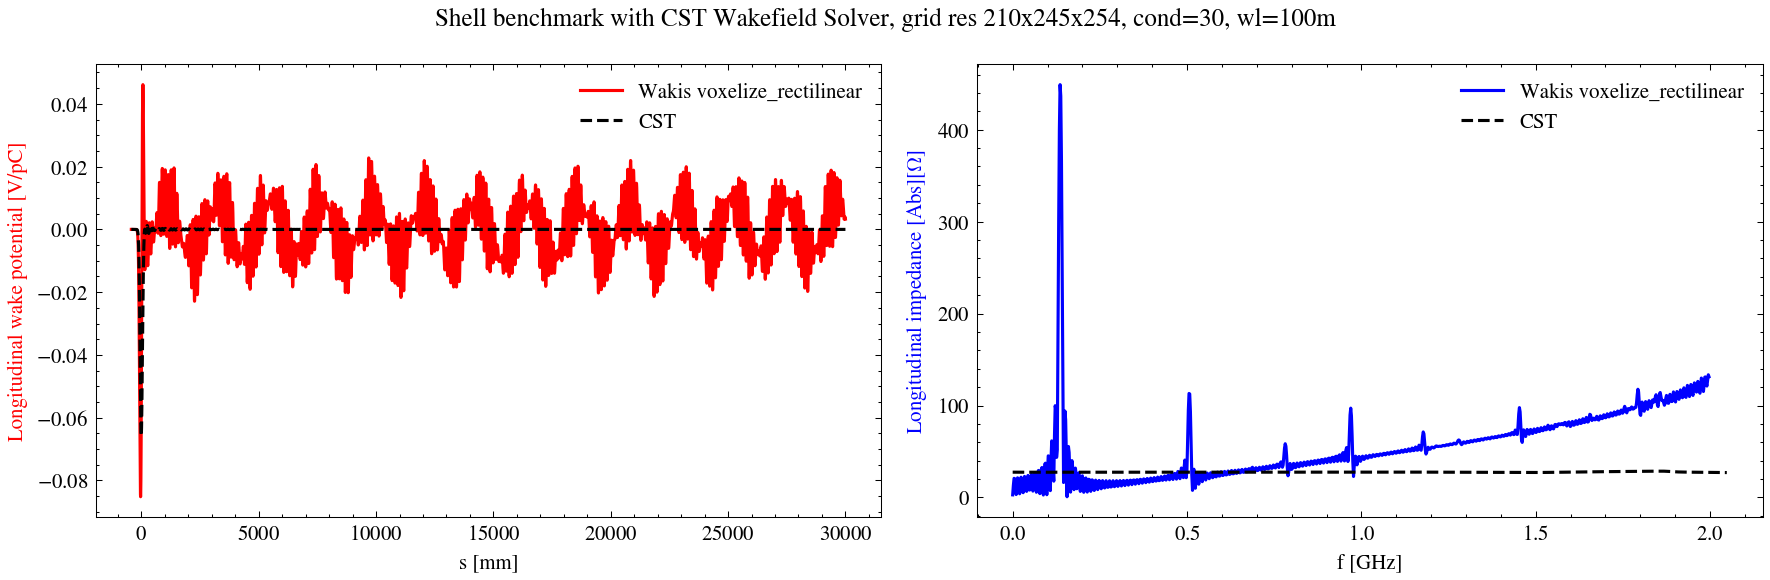

In [ ]:
%matplotlib ipympl
plt.style.use(['science','no-latex'])

compare_to_CST = True
fig, ax = plt.subplots(1, 2, figsize=[12, 4], dpi=150)

#ax[0].plot(wake.s * 1e2, wake.lambdas *  wake.WP.max()/wake.lambdas.max(), c='orange', label='Beam current' )
#ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis v0.7.0 enclosed_points")
#ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis Interior_points")
#ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis Implicit_distance")
#ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis voxelize_rectilinear")
#ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis voxelize_rectilinear (no shift)")
#ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis voxelize_rectilinear")
ax[0].plot(WP[:,0]* 1e3, WP[:,1], c="r", lw=1.5, label="Wakis voxelize_rectilinear")
ax[0].set_xlabel("s [mm]")
ax[0].set_ylabel("Longitudinal wake potential [V/pC]", color="r")
ax[0].legend()

#ax[1].plot(wake.f * 1e-9, np.abs(wake.lambdaf) *  np.abs(wake.Z).max()/wake.lambdaf.max(), c='grey', label='Beam Spectrum' )
#ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis v0.7.0 enclosed_points")
#ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis Interior_points")
#ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis Implicit_distance")
#ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis voxelize_rectilinear")
#ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis voxelize_rectilinear (no shift)")
#ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis voxelize_rectilinear")
ax[1].plot(Z[:,0]* 1e-9, np.abs(Z[:,1]), c="b", lw=1.5, label="Wakis voxelize_rectilinear")
ax[1].set_xlabel("f [GHz]")
ax[1].set_ylabel("Longitudinal impedance [Abs][$\Omega$]", color="b")
ax[1].legend()

if compare_to_CST:
    # CST wake and impedace data:
    #cstWP = wake.read_txt("/home/cwimmelm/wakis/benchmarks/CST/WP_wl10000.txt")
    #cstZ = wake.read_txt("/home/cwimmelm/wakis/benchmarks/CST/Z_wl10000.txt")
    #cstWP = np.loadtxt("/home/cwimmelm/wakis/clara_benchmarks/CST/shell/WP_cond30_wl10000.txt", skiprows=2, delimiter=None, usecols=None)
    #cstWP=np.loadtxt("/home/cwimmelm/wakis/benchmarks/CST/shell/WP_cond10_wl4000.txt", skiprows=2,delimiter=None, usecols=None)
    #cstZ=np.loadtxt("/home/cwimmelm/wakis/clara_benchmarks/CST/shell/Z_cond30_wl10000.txt", skiprows=2,delimiter=None, usecols=None)
    #cstZ=np.loadtxt("/home/cwimmelm/wakis/benchmarks/CST/shell/Z_cond10_wl4000.txt", skiprows=2,delimiter=None, usecols=None)
    ax[0].plot(cstWP[:,0], cstWP[:,1], c="k", ls="--", lw=1.5, label="CST")
    ax[1].plot(cstZ[:,0], cstZ[:,1], c="k", ls="--", lw=1.5, label="CST")
    #fig.suptitle("Shell benchmark with CST Wakefield Solver, grid res 210x245x254, cond=30, wl=100m")
    ax[0].legend()
    ax[1].legend()


fig.tight_layout()
fig.savefig(f"{result_folder}/benchmark_unitCorrection.png")


In [ ]:
plt.style.use(['science','ieee'])

# Compare to benchmark data, if available
compare_to_CST = True 

fig, ax = plt.subplots(1, 2, figsize=[12, 4], dpi=150)
ax[0].plot(wake.s * 1e2, wake.WP, c="r", lw=1.5, label="Wakis")
ax[0].set_xlabel("s [cm]")
ax[0].set_ylabel("Longitudinal wake potential [V/pC]", color="r")
ax[0].legend()

ax[1].plot(wake.f * 1e-9, np.abs(wake.Z), c="b", lw=1.5, label="Wakis")
ax[1].set_xlabel("f [GHz]")
ax[1].set_ylabel("Longitudinal impedance [Abs][$\Omega$]", color="b")
ax[1].legend()

if compare_to_CST:
    # CST wake and impedace data:
    cstWP = wake.read_txt("cst/WP.txt")
    cstZ = wake.read_txt("cst/Z.txt")
    ax[0].plot(cstWP[0], cstWP[1], c="k", ls="--", lw=1.5, label="CST")
    ax[1].plot(cstZ[0], cstZ[1], c="k", ls="--", lw=1.5, label="CST")
    fig.suptitle("Benchmark with CST Wakefield Solver")

fig.tight_layout()
fig.savefig("001_results/benchmark000.png")